In [553]:
!pip install FDApy

In [554]:
import matplotlib.pyplot as plt
import numpy as np

from FDApy.representation import DenseArgvals, DenseValues
from FDApy.simulation import KarhunenLoeve
from FDApy.preprocessing import UFPCA
from FDApy.visualization import plot
from FDApy import DenseFunctionalData

# Introduction

In this notebook, we applied Functional Principal Component Analysis (FPCA) to a toy problem involving polynomial functions contaminated with noise on a finite grid. The primary goal was to assess FPCA’s ability to recover the underlying polynomial structure and, in effect, predict the polynomial order. We chose the FDApy library for this study because it is actively maintained and offers a robust implementation of FPCA, compared to alternatives like scikit‑fda.

The notebook is organized into several sections that differ according to the data conditions:

1. Neighborhood of Zero
    – Experiments using functions defined on a domain centered at zero.

2. Non‑Neighborhood of Zero
    – Experiments where the domain is shifted away from zero.

3. Strong Noise
    – Experiments where the observation noise level is low enough not to overwhelm the signal and, separately, where it is so high that it dominates the underlying function.

For each case, three different FPCA configurations were tested:

- Insufficient Number of Components: Using a low number of components that are expected to be too few for an accurate reconstruction.
- Exact Number of Components: Using a number of components equal to the true polynomial order.
- Adaptive Number of Components: Automatically selecting the number of components to explain a given proportion (e.g., 99%) of the total variance.

# Neighborhood of Zero

**Data Generation:**
- Polynomial Functions: 60 functions were generated based on an 8th‑degree polynomial.
- Domain: The functions are evaluated on 100 evenly spaced points between –3 and 3.
- Coefficient Generation: Coefficients were drawn from a normal distribution (scaled by a margin of 3) to form each polynomial.
- Noise: High‑amplitude noise was added (each function had noise values drawn from a normal distribution and multiplied by 1000) to simulate significant measurement error.
- True vs. Observed Data: Two sets were created—one with the noisy observations and one with the noise‑free (true) function values.

**Data Representation:**  Both the noisy functions and the true functions were converted into the “DenseFunctionalData” format provided by FDApy.

In [555]:
polynom_power = 8 # polynomial degree
function_count = 60 

margin = 3

# domain
argvals = np.linspace(-margin, margin, num=100)

# observations
X = []
X_true = []
np.random.seed(3)

for i in range(function_count):
    coefs = np.random.randn(polynom_power) * margin
    poly = np.poly1d(coefs, r=True)
    noise = np.random.randn(100) * 1000
    # noisy observations
    X.append(poly(argvals) + noise)
    # true observations
    X_true.append(poly(argvals))

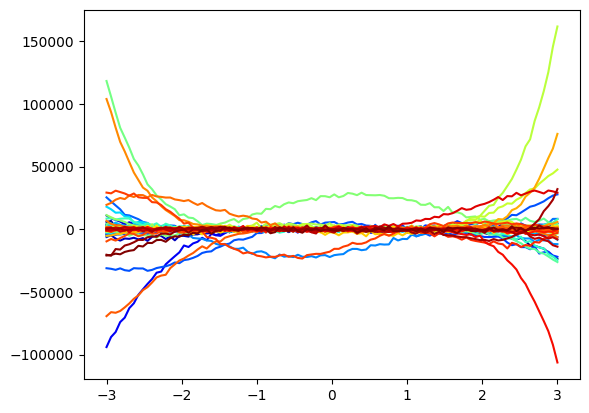

In [556]:
data = DenseFunctionalData(
    argvals=DenseArgvals({"input_dim_0": argvals}), values=DenseValues(X)
)

data_true = DenseFunctionalData(
    argvals=DenseArgvals({"input_dim_0": argvals}), values=DenseValues(X_true)
)

_ = plot(data)

## Insufficient Number of Components
FPCA was applied using only 3 components.

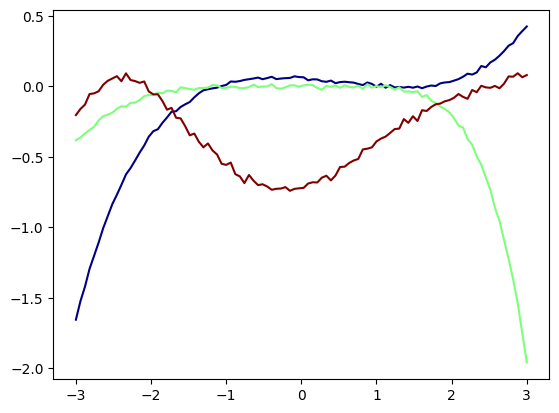

In [557]:
# 1-dim FPCA, decompositiopn of covariance operator
ufpca_cov_3_comp = UFPCA(n_components=3, method="covariance")
ufpca_cov_3_comp.fit(data)

# extracted eigenfunctions 
_ = plot(ufpca_cov_3_comp.eigenfunctions)
plt.show()

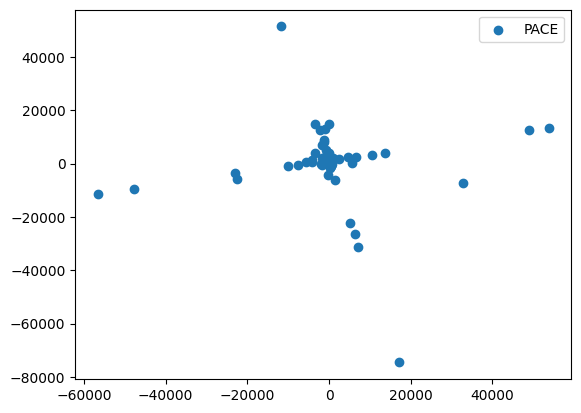

In [558]:
# PACE method
scores_pace_3_comp = ufpca_cov_3_comp.transform(data, method="PACE")

plt.scatter(scores_pace_3_comp[:, 0], scores_pace_3_comp[:, 1], label="PACE")
plt.legend()
plt.show()

### Observations

3 components were not sufficient to capture the full shape of the underlying functions.

An inverse transformation (reconstruction) showed that the basis was too limited to accurately restore the original functions.

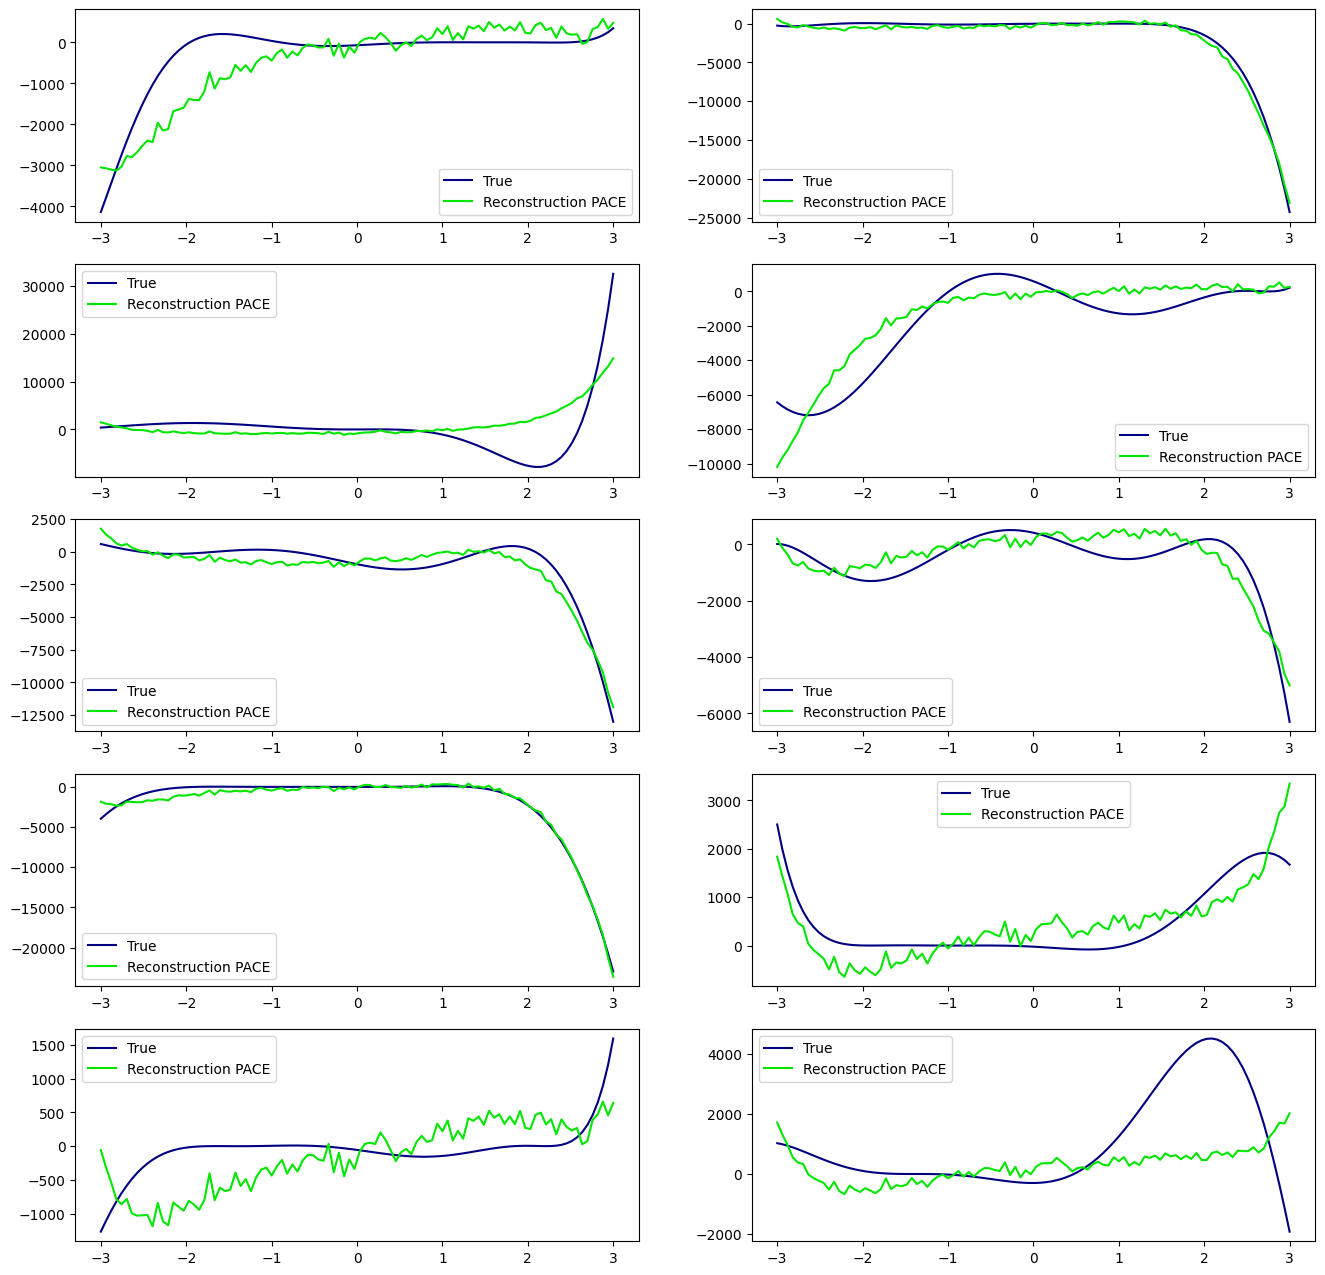

In [559]:
data_recons_pace = ufpca_cov_3_comp.inverse_transform(scores_pace_3_comp)

colors_pace = np.array([[0, 0.9, 0, 1]])

np.random.seed(3)

# 10 random observations
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 16))
for idx_plot, idx in enumerate(np.random.choice(function_count, 10)):
    temp_ax = axes.flatten()[idx_plot]
    temp_ax = plot(data_true[idx], ax=temp_ax, label="True")
    plot(
        data_recons_pace[idx],
        colors=colors_pace,
        ax=temp_ax,
        label="Reconstruction PACE",
    )
    temp_ax.legend()
plt.show()

## Exact Number of Components
FPCA was performed using exactly 8 components (matching the polynomial order).



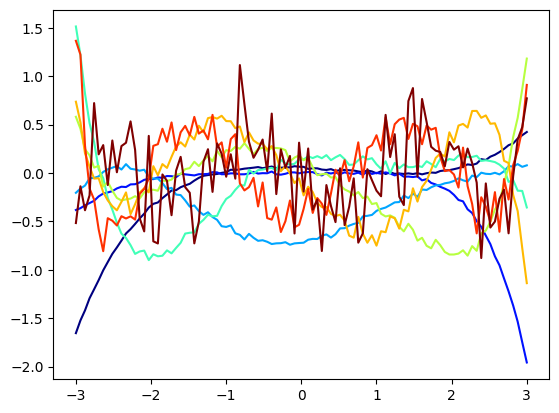

In [560]:
ufpca_cov_p_comp = UFPCA(n_components=polynom_power, method="covariance")
ufpca_cov_p_comp.fit(data)

_ = plot(ufpca_cov_p_comp.eigenfunctions)
plt.show()

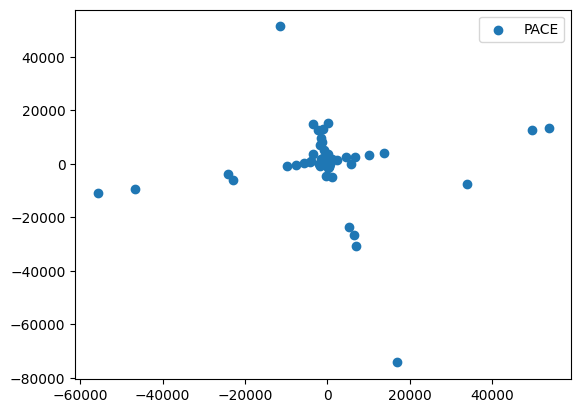

In [561]:
scores_pace_p_comp = ufpca_cov_p_comp.transform(data, method="PACE")

plt.scatter(scores_pace_p_comp[:, 0], scores_pace_p_comp[:, 1], label="PACE")
plt.legend()
plt.show()

### Observation

The eigenfunctions were much closer in shape to the true functions, and the FPCA scores indicated a better representation of the data.

The reconstruction improved relative to the 3‑component case, although the inherent noise still prevented perfect recovery.

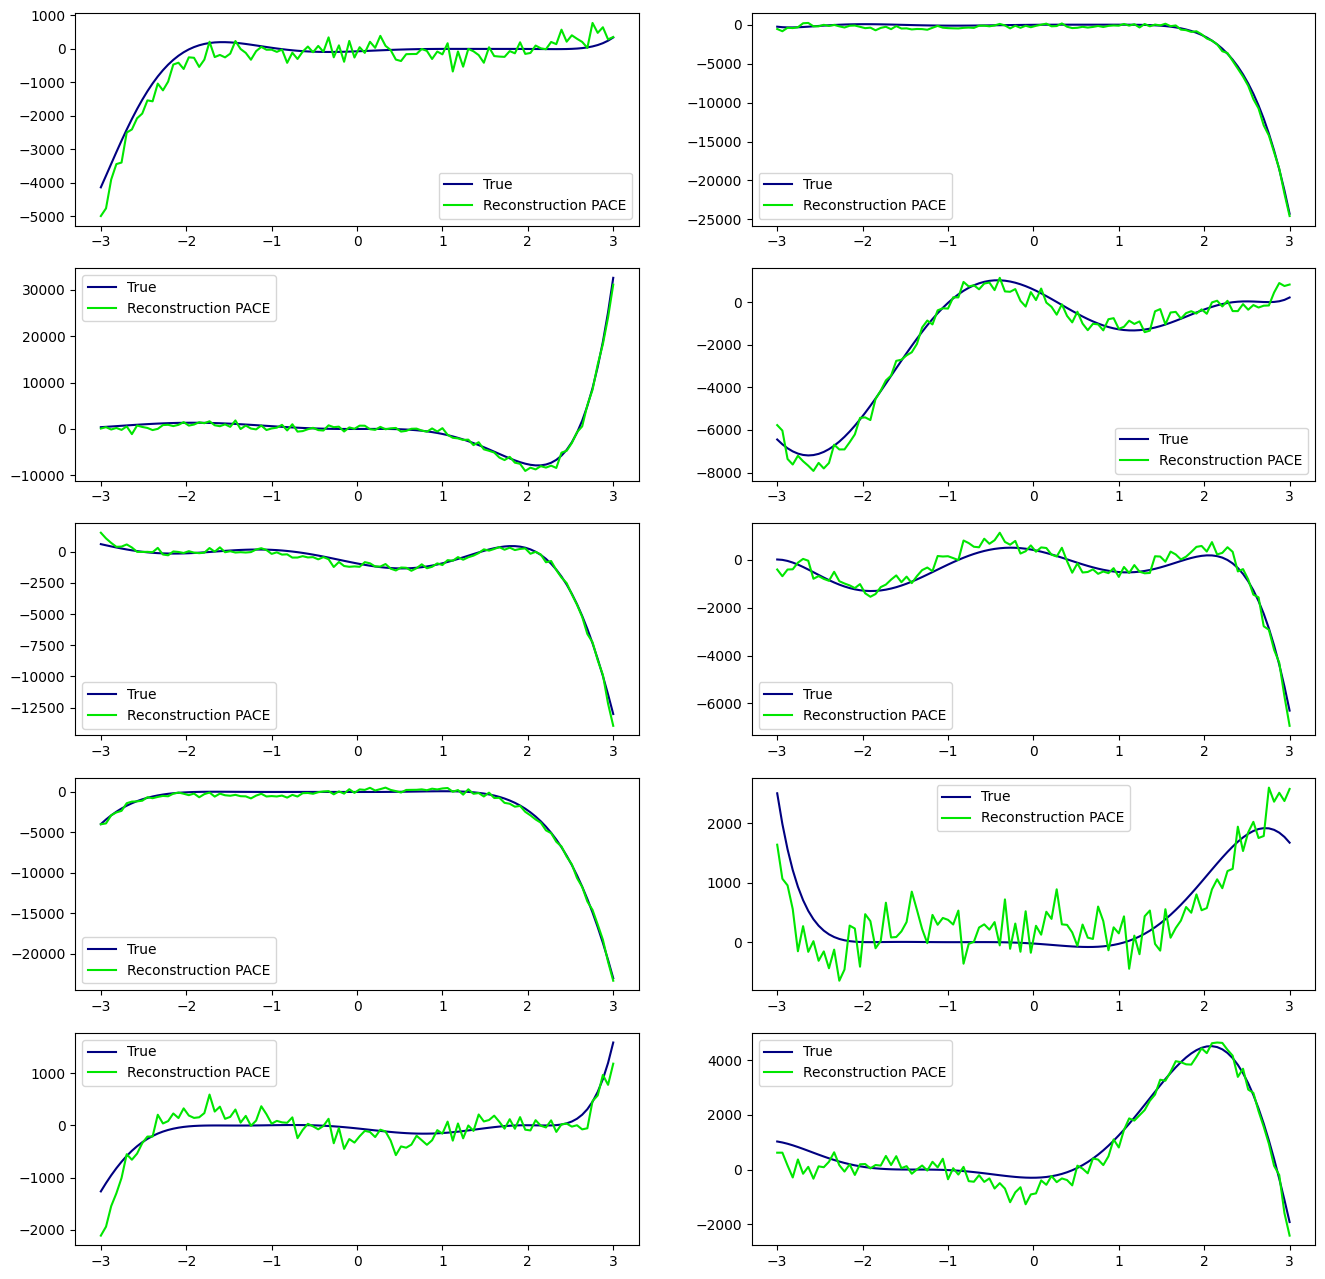

In [562]:
data_recons_pace = ufpca_cov_p_comp.inverse_transform(scores_pace_p_comp)
colors_pace = np.array([[0, 0.9, 0, 1]])

np.random.seed(3)

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 16))
for idx_plot, idx in enumerate(np.random.choice(function_count, 10)):
    temp_ax = axes.flatten()[idx_plot]
    temp_ax = plot(data_true[idx], ax=temp_ax, label="True")
    plot(
        data_recons_pace[idx],
        colors=colors_pace,
        ax=temp_ax,
        label="Reconstruction PACE",
    )
    temp_ax.legend()
plt.show()

## Adaptive Number of Components

FPCA was configured to automatically select enough components to explain 99% of the variance.

The method selected 7 components, which is close to the true number (8).


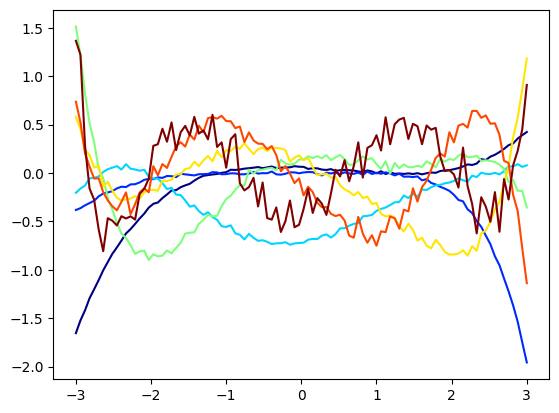

In [563]:
ufpca_cov_a_comp = UFPCA(n_components=0.99, method="covariance")
ufpca_cov_a_comp.fit(data)

_ = plot(ufpca_cov_a_comp.eigenfunctions)
plt.show()

In [564]:
ufpca_cov_a_comp.eigenfunctions

Functional data object with 7 observations on a 1-dimensional support.

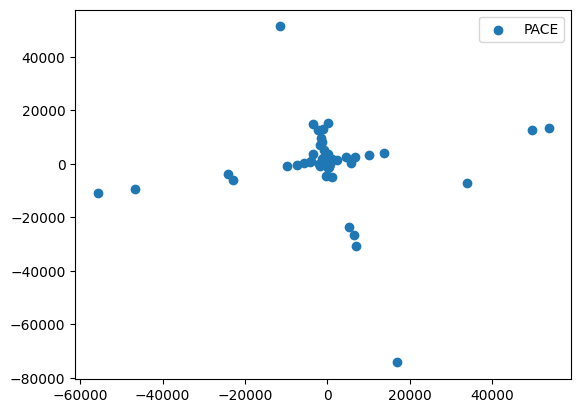

In [565]:

scores_pace_a_comp = ufpca_cov_a_comp.transform(data, method="PACE")

plt.scatter(scores_pace_a_comp[:, 0], scores_pace_a_comp[:, 1], label="PACE")
plt.legend()
plt.show()

### Observations

The reconstruction and FPCA scores were intermediate between the insufficient and exact cases, suggesting that the adaptive approach works reasonably well when the signal is dominant over noise.


When the domain is centered at zero, the underlying polynomial structure is complex enough that too few components fail to capture the signal, while using the exact number of components or an adaptive threshold improves recovery. However, even the best reconstructions are affected by the high noise level.

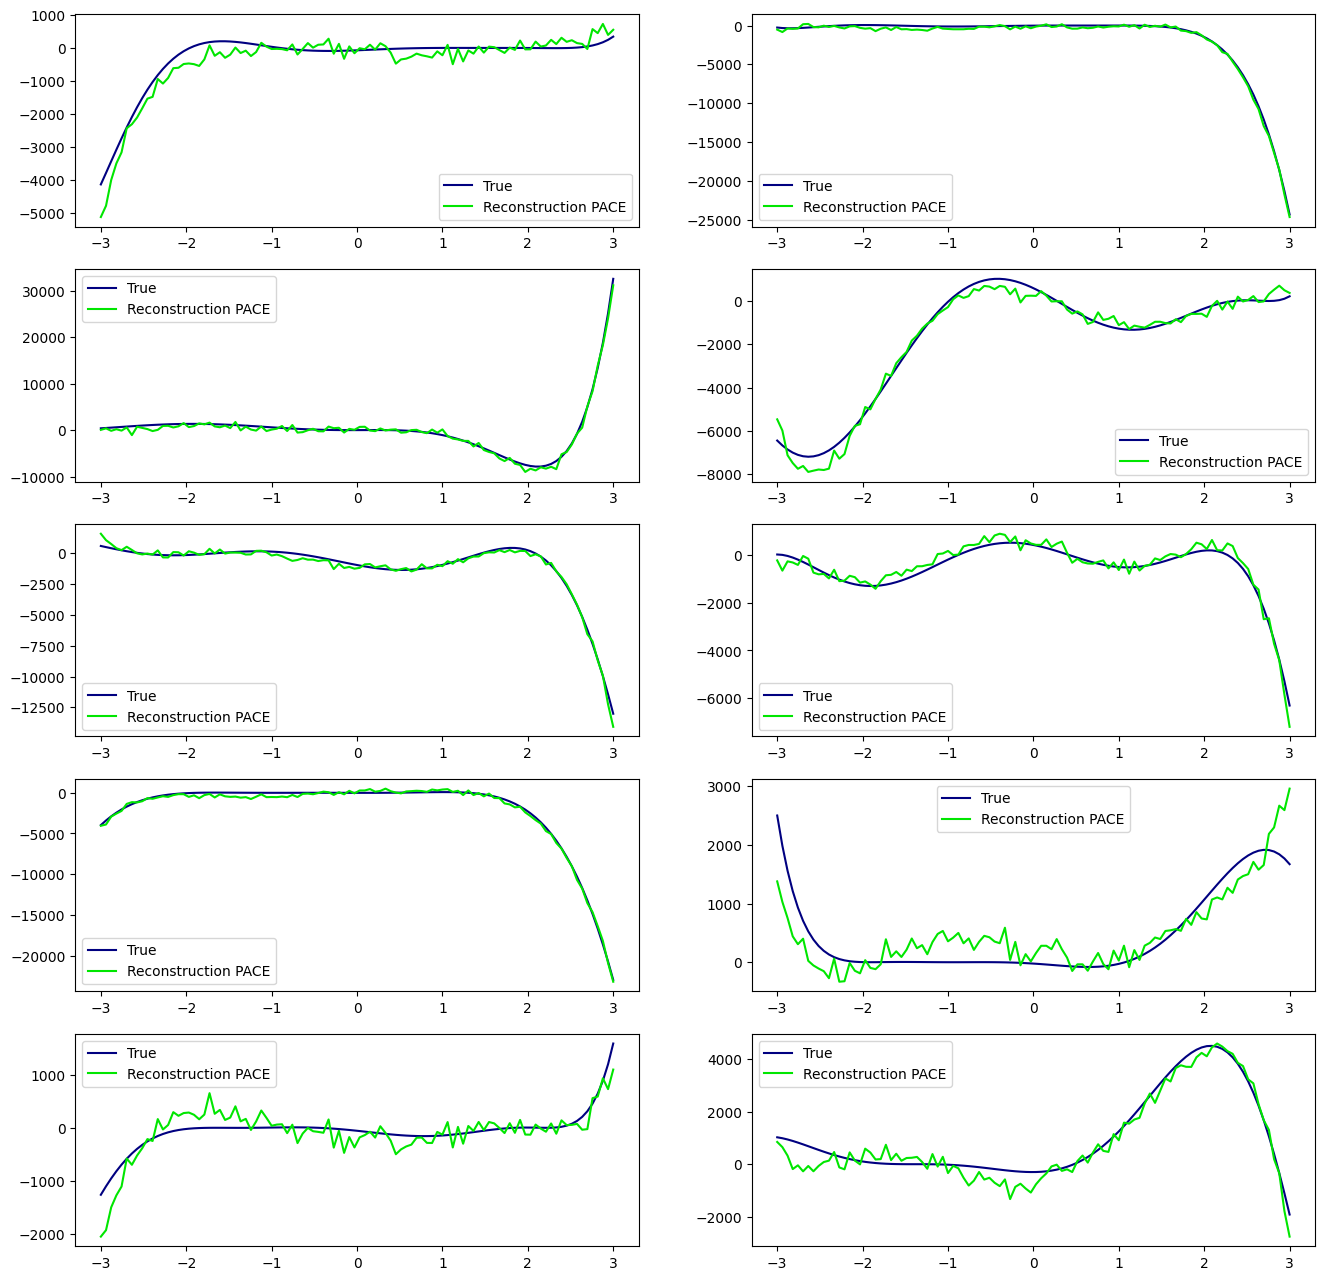

In [566]:
data_recons_pace = ufpca_cov_a_comp.inverse_transform(scores_pace_a_comp)
colors_pace = np.array([[0, 0.9, 0, 1]])
np.random.seed(3)

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 16))
for idx_plot, idx in enumerate(np.random.choice(function_count, 10)):
    temp_ax = axes.flatten()[idx_plot]
    temp_ax = plot(data_true[idx], ax=temp_ax, label="True")
    plot(
        data_recons_pace[idx],
        colors=colors_pace,
        ax=temp_ax,
        label="Reconstruction PACE",
    )
    temp_ax.legend()
plt.show()

# Non‑Neighborhood of Zero

Data Generation:
- The same procedure was used to generate 60 polynomial functions, but this time the domain was shifted.
- Domain: The functions are evaluated on 100 points between 2 and 4 (using a margin of 1 around the center value of 3).
- Noise: Noise was added in the same manner as before (using a high noise multiplier).

In [567]:
polynom_power = 8 
function_count = 60

margin = 1
argvals = np.linspace(3 - margin, 3 + margin, num=100)

X = []
X_true = []
np.random.seed(3)

for i in range(function_count):
    coefs = np.random.randn(polynom_power) * margin
    poly = np.poly1d(coefs, r=True)
    noise = np.random.randn(100) * 1000
    X.append(poly(argvals) + noise)
    X_true.append(poly(argvals))

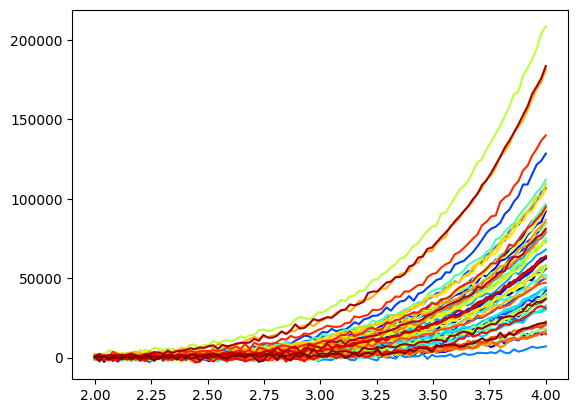

In [568]:
data = DenseFunctionalData(
    argvals=DenseArgvals({"input_dim_0": argvals}), values=DenseValues(X)
)

data_true = DenseFunctionalData(
    argvals=DenseArgvals({"input_dim_0": argvals}), values=DenseValues(X_true)
)

_ = plot(data)

## Insufficient Number of Components:

- FPCA was applied with 3 components.
- In this setting, because the polynomial’s dominant term is more pronounced away from zero, even a low number of components could capture most of the variation.

   

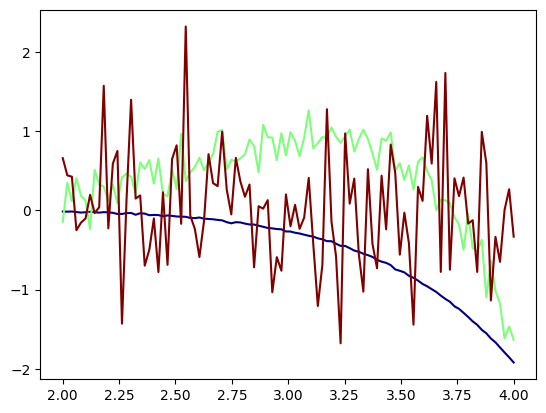

In [569]:
ufpca_cov_3_comp = UFPCA(n_components=3, method="covariance")
ufpca_cov_3_comp.fit(data)

_ = plot(ufpca_cov_3_comp.eigenfunctions)
plt.show()

In [570]:
scores_pace_3_comp = ufpca_cov_3_comp.transform(data, method="PACE")

### Observation

Reconstruction showed that the dominant behavior of the functions was relatively well captured.

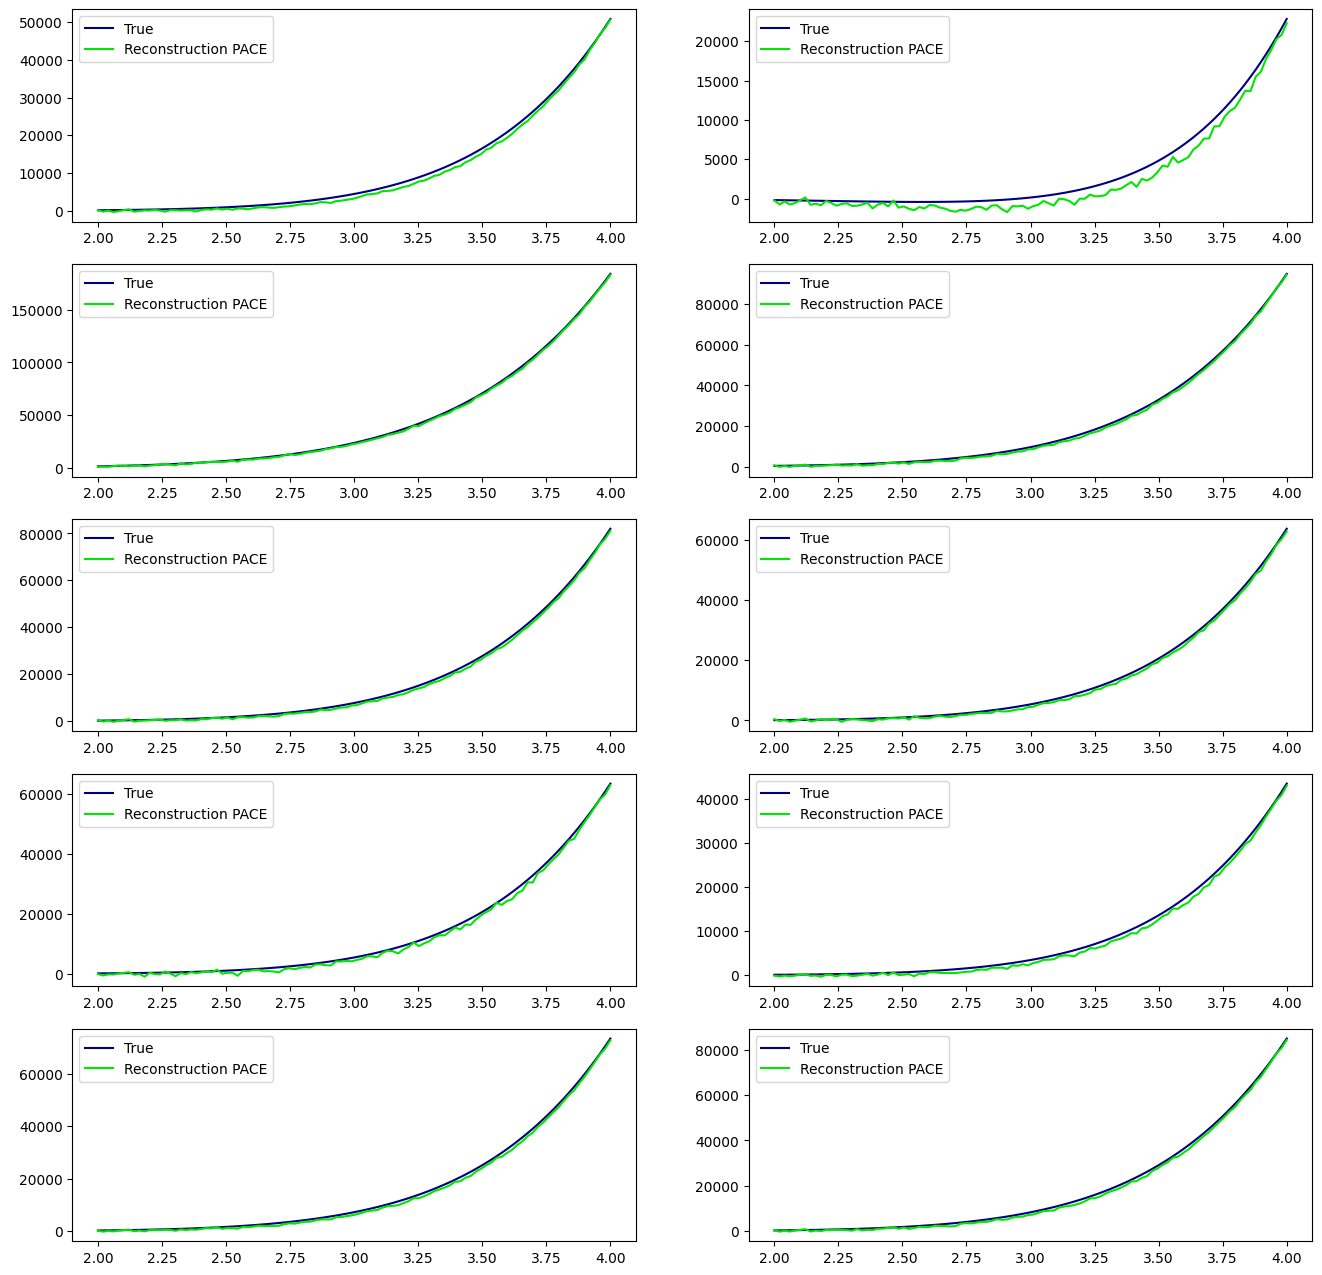

In [571]:
data_recons_pace = ufpca_cov_3_comp.inverse_transform(scores_pace_3_comp)
colors_pace = np.array([[0, 0.9, 0, 1]])

np.random.seed(3)

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 16))
for idx_plot, idx in enumerate(np.random.choice(function_count, 10)):
    temp_ax = axes.flatten()[idx_plot]
    temp_ax = plot(data_true[idx], ax=temp_ax, label="True")
    plot(
        data_recons_pace[idx],
        colors=colors_pace,
        ax=temp_ax,
        label="Reconstruction PACE",
    )
    temp_ax.legend()
plt.show()

## Exact Number of Components:

FPCA with 8 components produced eigenfunctions nearly identical to the true functions, indicating that extra components beyond the dominant ones added little new information.

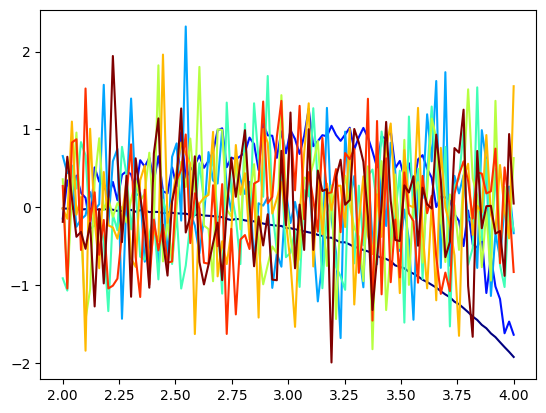

In [572]:
ufpca_cov_p_comp = UFPCA(n_components=polynom_power, method="covariance")
ufpca_cov_p_comp.fit(data)

_ = plot(ufpca_cov_p_comp.eigenfunctions)
plt.show()

In [573]:
scores_pace_p_comp = ufpca_cov_p_comp.transform(data, method="PACE")

### Observations

As mentioned above, when almost all components of the polynomial are dominated by the largest one, adding additional components to the decomposition will not improve the already good behavior. The graphs are almost indistinguishable visually, and the added components, as can be seen from the graph above the scoring, are rather noisy.

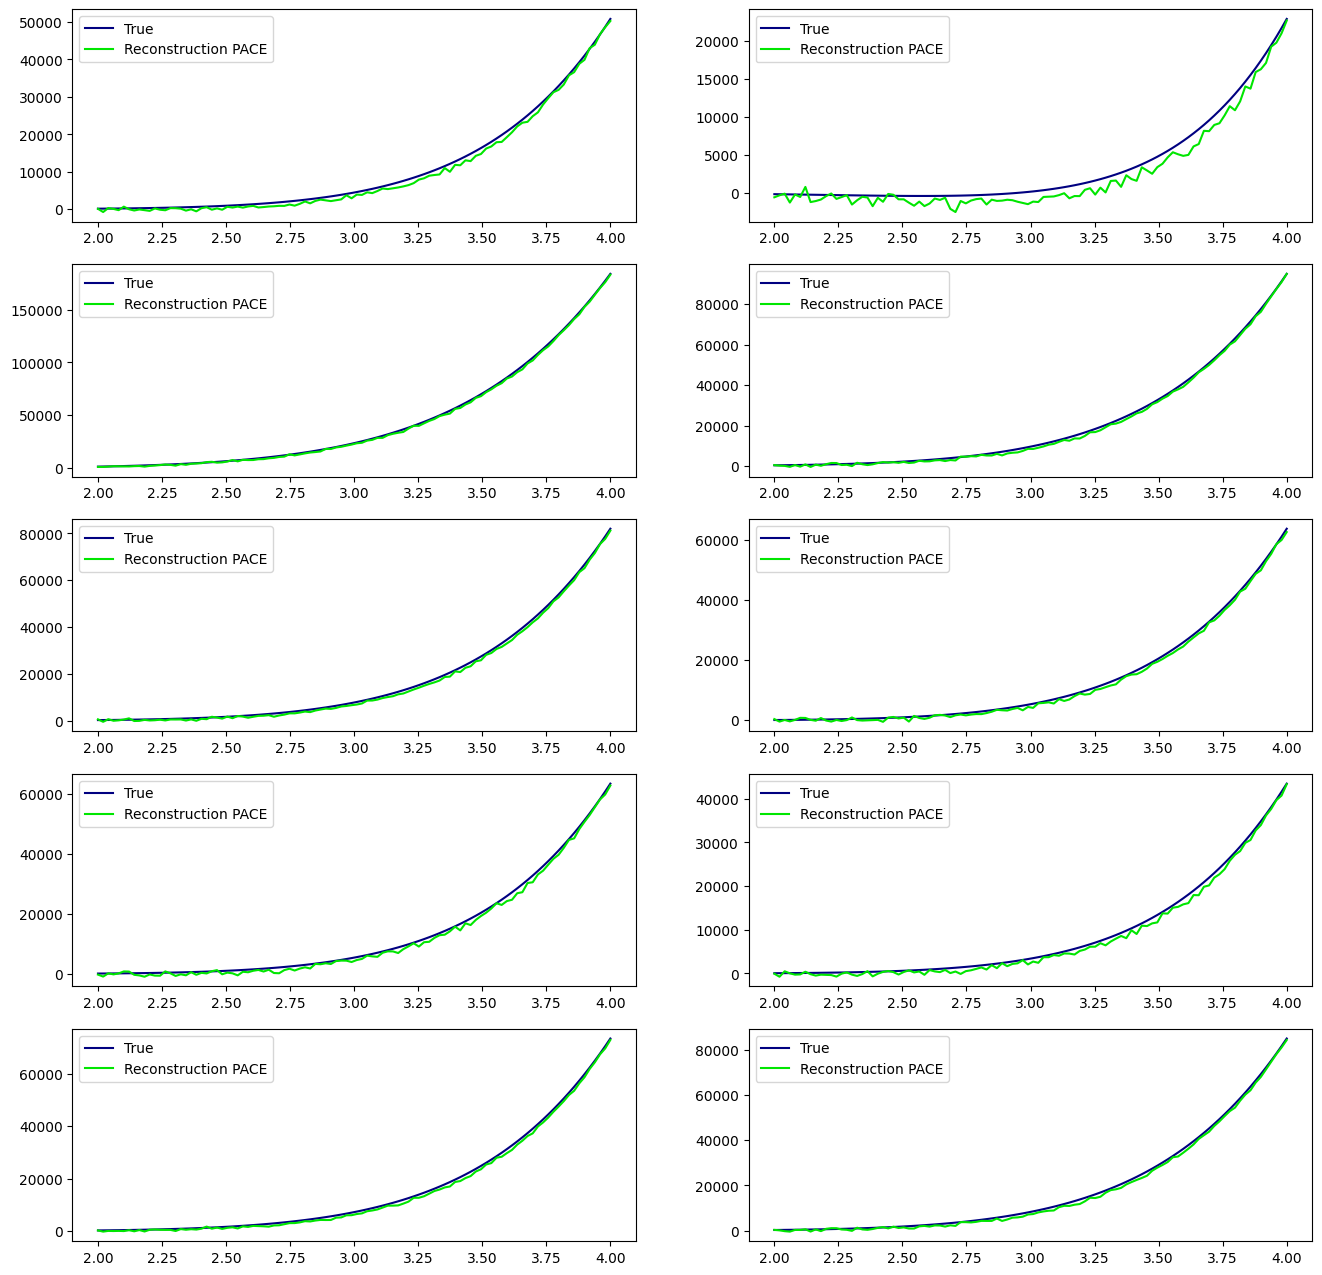

In [574]:
data_recons_pace = ufpca_cov_p_comp.inverse_transform(scores_pace_p_comp)

colors_pace = np.array([[0, 0.9, 0, 1]])

np.random.seed(3)
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 16))
for idx_plot, idx in enumerate(np.random.choice(function_count, 10)):
    temp_ax = axes.flatten()[idx_plot]
    temp_ax = plot(data_true[idx], ax=temp_ax, label="True")
    plot(
        data_recons_pace[idx],
        colors=colors_pace,
        ax=temp_ax,
        label="Reconstruction PACE",
    )
    temp_ax.legend()
plt.show()

## Decomposition with explained variance

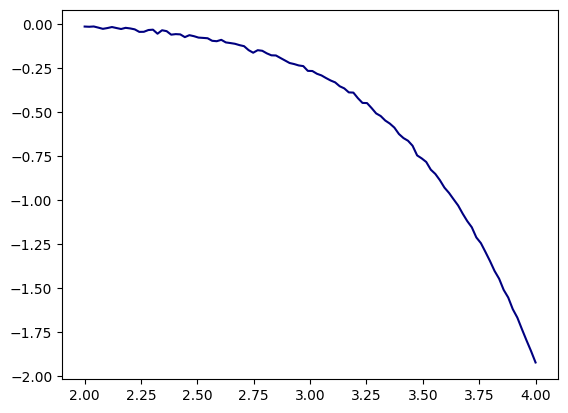

In [575]:
# FPCA was set to select components adaptively to explain 99% of the variance.
ufpca_cov_a_comp = UFPCA(n_components=0.99, method="covariance")
ufpca_cov_a_comp.fit(data)

_ = plot(ufpca_cov_a_comp.eigenfunctions)
plt.show()

In [576]:
ufpca_cov_a_comp.eigenfunctions

Functional data object with 1 observations on a 1-dimensional support.

In [577]:
scores_pace_a_comp = ufpca_cov_a_comp.transform(data, method="PACE")

### Observations:
When the domain is shifted away from zero, one term of the polynomial tends to dominate, and even an insufficient number of components (e.g., 3) may capture most of the essential behavior. The exact number of components does not significantly improve the reconstruction since the signal is already dominated by the leading behavior.

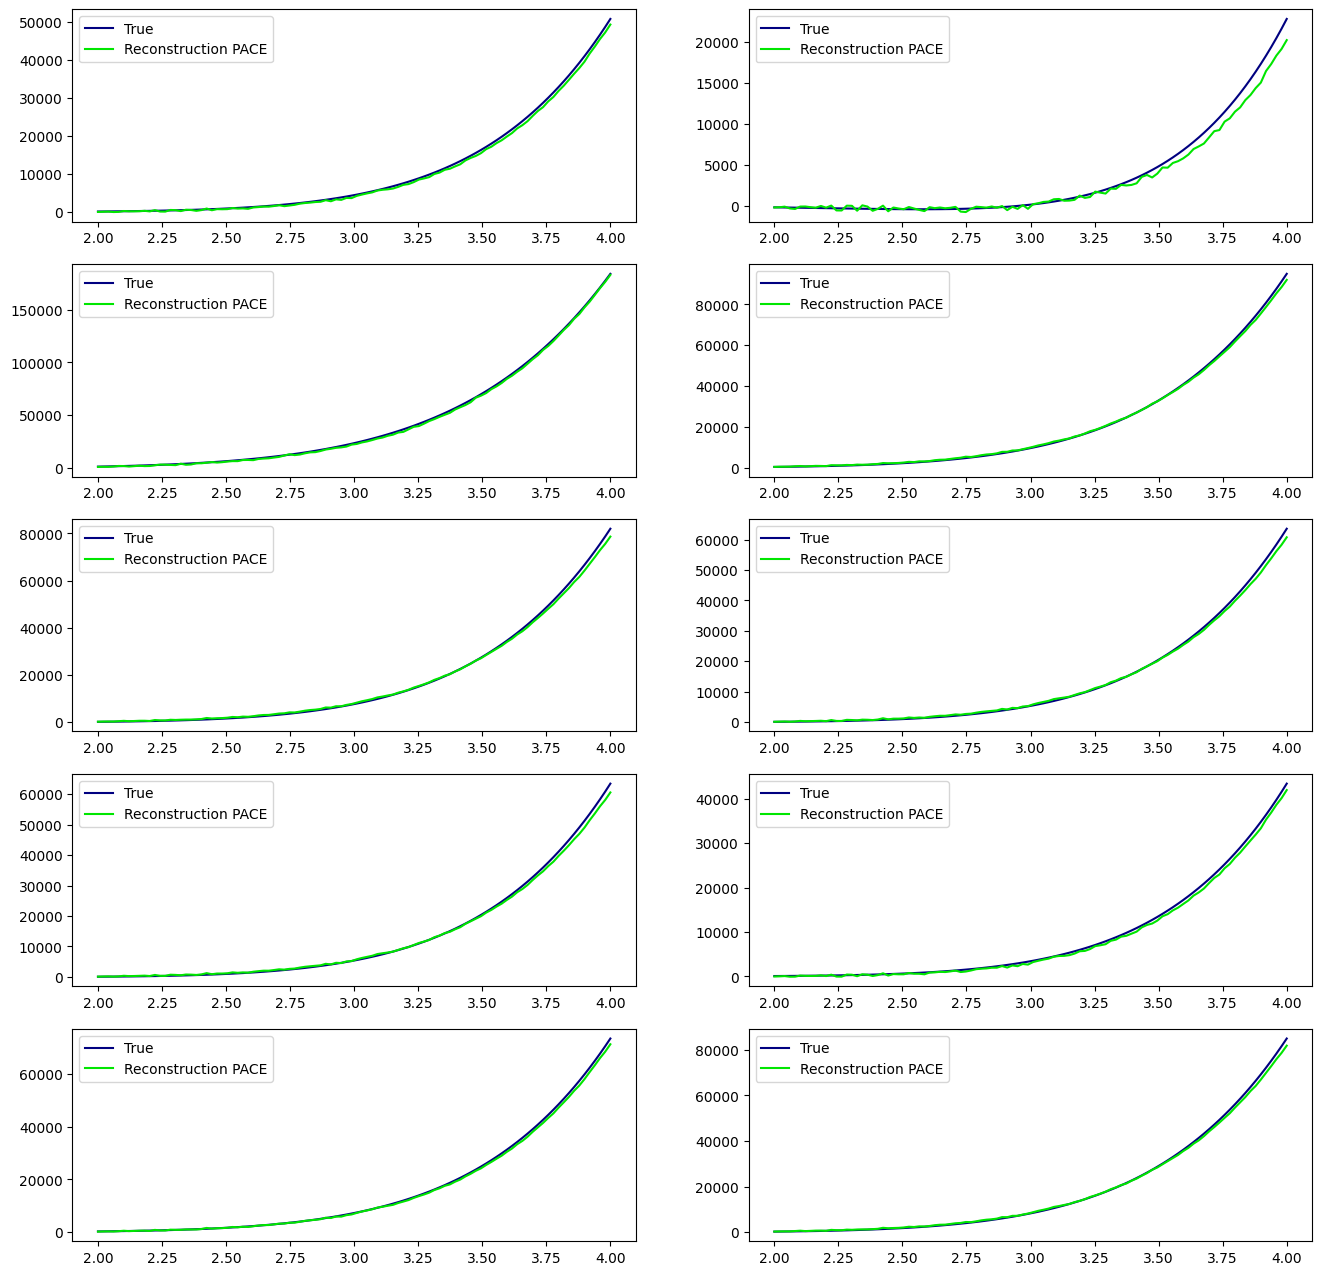

In [578]:
data_recons_pace = ufpca_cov_a_comp.inverse_transform(scores_pace_a_comp)

colors_pace = np.array([[0, 0.9, 0, 1]])

np.random.seed(3)

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 16))
for idx_plot, idx in enumerate(np.random.choice(function_count, 10)):
    temp_ax = axes.flatten()[idx_plot]
    temp_ax = plot(data_true[idx], ax=temp_ax, label="True")
    plot(
        data_recons_pace[idx],
        colors=colors_pace,
        ax=temp_ax,
        label="Reconstruction PACE",
    )
    temp_ax.legend()
plt.show()

# Strong Noise

**Data Generation:**
- Again, 60 functions were generated based on an 8th‑degree polynomial.
- Domain: The functions are evaluated on 100 points between –1 and 1.
- Noise: In this scenario, the noise amplitude is reduced (multiplied by 1 instead of 1000), representing a case with strong noise relative to the small signal amplitude.


In [579]:
polynom_power = 8
function_count = 60 

margin = 1

argvals = np.linspace(-margin, margin, num=100)

X = []
X_true = []
np.random.seed(3)

for i in range(function_count):
    coefs = np.random.randn(polynom_power) * margin
    poly = np.poly1d(coefs, r=True)
    noise = np.random.randn(100) * 1
    X.append(poly(argvals) + noise)
    X_true.append(poly(argvals))

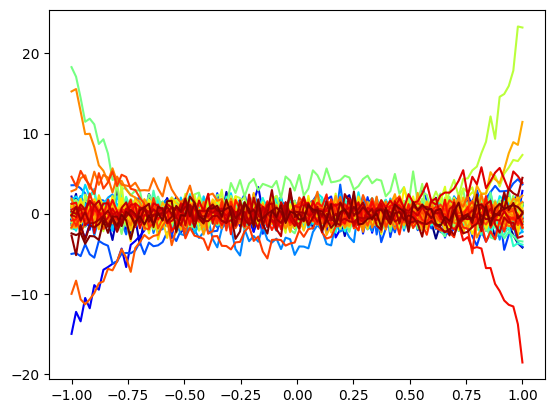

In [580]:
# The functions (noisy and true) were converted into the DenseFunctionalData format.
data = DenseFunctionalData(
    argvals=DenseArgvals({"input_dim_0": argvals}), values=DenseValues(X)
)

data_true = DenseFunctionalData(
    argvals=DenseArgvals({"input_dim_0": argvals}), values=DenseValues(X_true)
)

_ = plot(data)

## Insufficient Number of Components
FPCA with 3 components was applied.

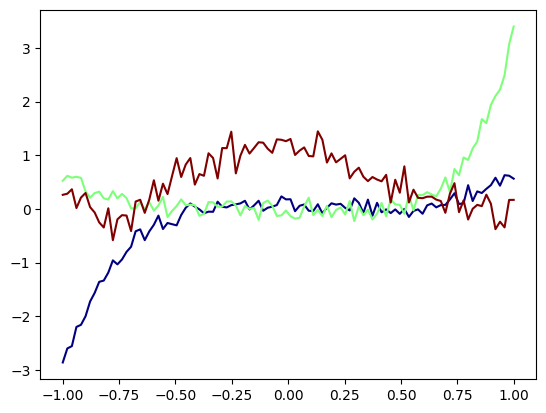

In [581]:
ufpca_cov_3_comp = UFPCA(n_components=3, method="covariance")
ufpca_cov_3_comp.fit(data)

_ = plot(ufpca_cov_3_comp.eigenfunctions)
plt.show()

In [582]:
scores_pace_3_comp = ufpca_cov_3_comp.transform(data, method="PACE")

### Observations
In high‑noise conditions, the 3‑component model did not capture the underlying function shape well, and the reconstruction error remained high.

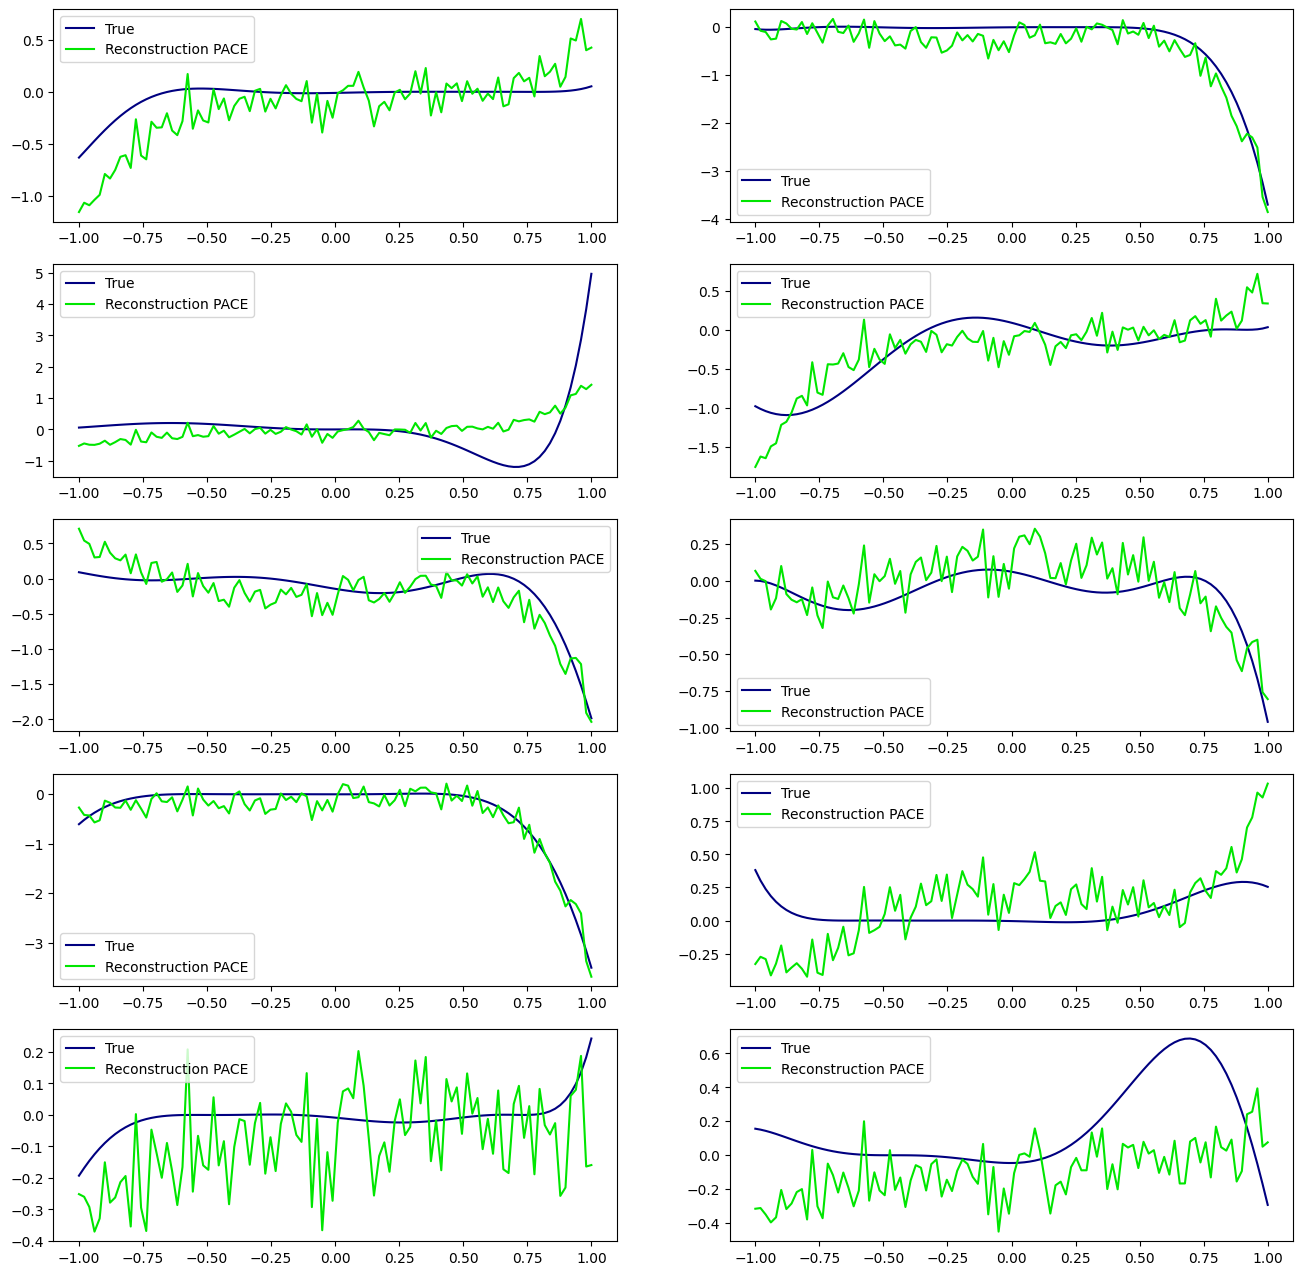

In [583]:
data_recons_pace = ufpca_cov_3_comp.inverse_transform(scores_pace_3_comp)
colors_pace = np.array([[0, 0.9, 0, 1]])

np.random.seed(3)

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 16))
for idx_plot, idx in enumerate(np.random.choice(function_count, 10)):
    temp_ax = axes.flatten()[idx_plot]
    temp_ax = plot(data_true[idx], ax=temp_ax, label="True")
    plot(
        data_recons_pace[idx],
        colors=colors_pace,
        ax=temp_ax,
        label="Reconstruction PACE",
    )
    temp_ax.legend()
plt.show()

## Exact Number of Components
FPCA with 8 components

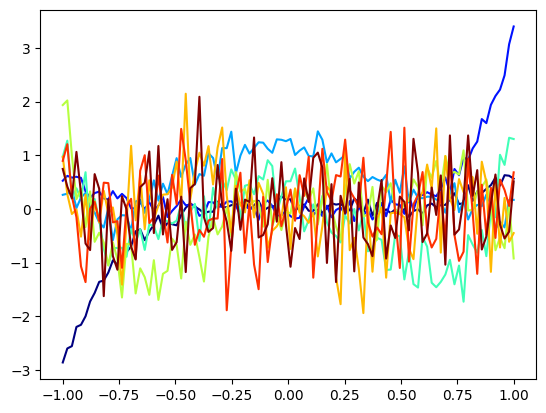

In [584]:
ufpca_cov_p_comp = UFPCA(n_components=polynom_power, method="covariance")
ufpca_cov_p_comp.fit(data)

_ = plot(ufpca_cov_p_comp.eigenfunctions)
plt.show()

In [585]:
scores_pace_p_comp = ufpca_cov_p_comp.transform(data, method="PACE")

### Observation

Although the eigenfunctions closely approximated the shape of the true functions, the presence of noise led to substantial distortion in the reconstruction. The noise was so significant that even an exact match in component number could not fully recover the original signal.

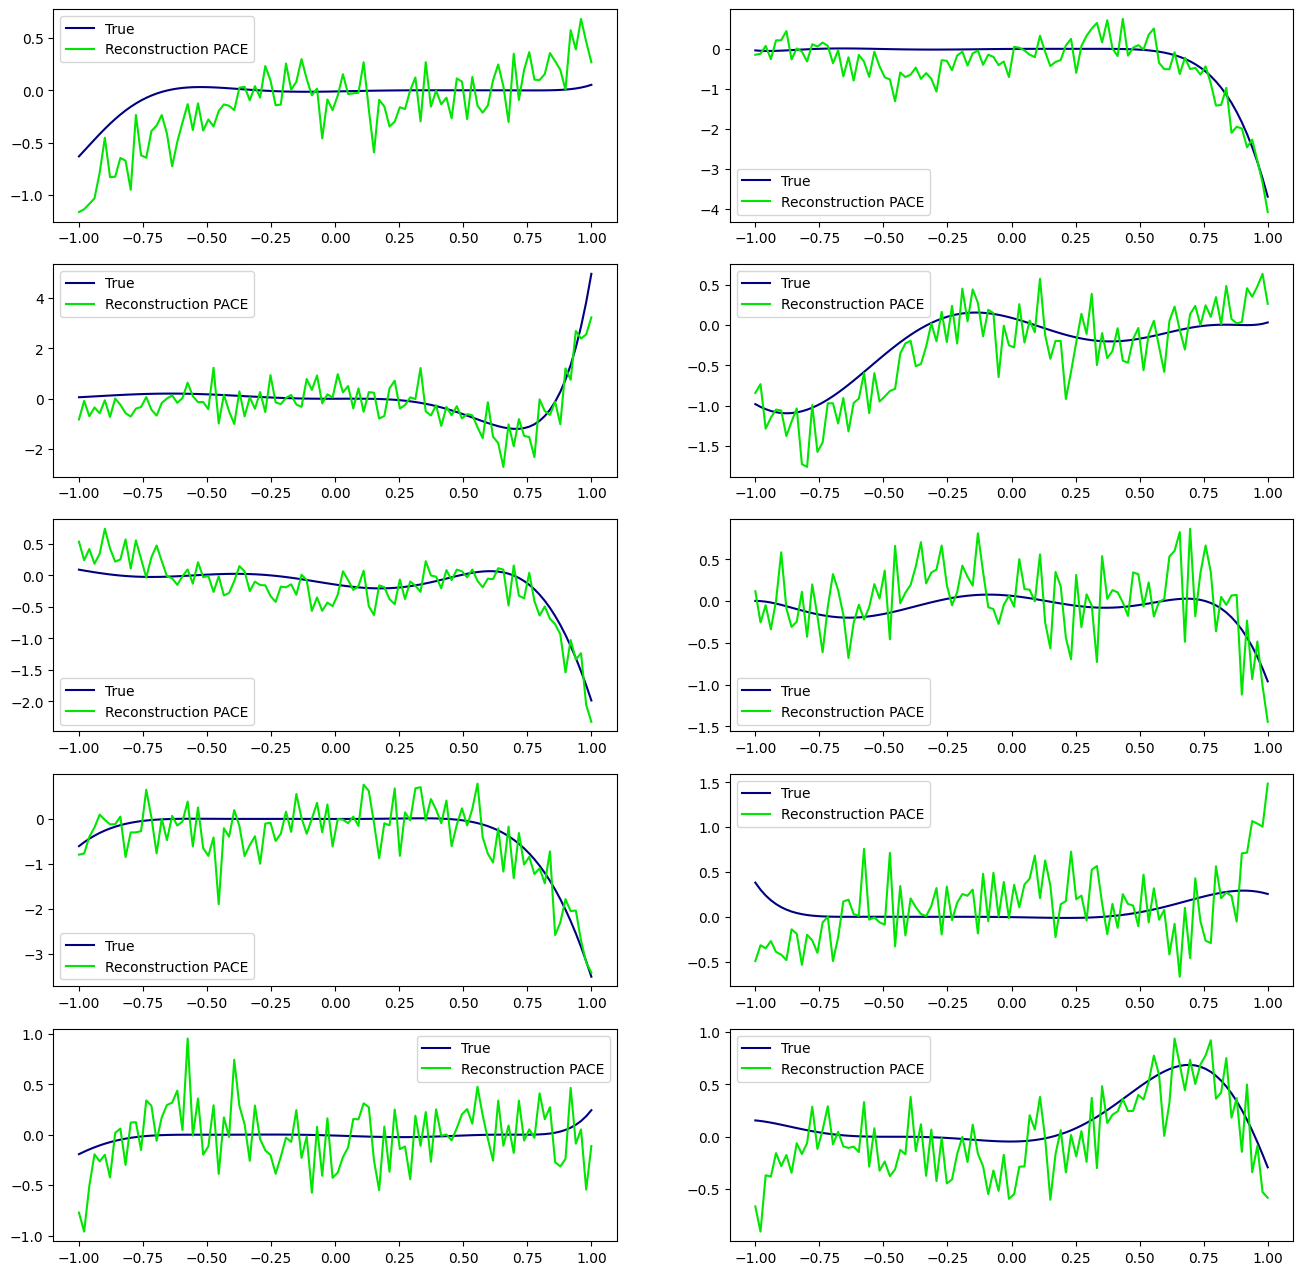

In [586]:
data_recons_pace = ufpca_cov_p_comp.inverse_transform(scores_pace_p_comp)
colors_pace = np.array([[0, 0.9, 0, 1]])

np.random.seed(3)

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 16))
for idx_plot, idx in enumerate(np.random.choice(function_count, 10)):
    temp_ax = axes.flatten()[idx_plot]
    temp_ax = plot(data_true[idx], ax=temp_ax, label="True")
    plot(
        data_recons_pace[idx],
        colors=colors_pace,
        ax=temp_ax,
        label="Reconstruction PACE",
    )
    temp_ax.legend()
plt.show()

## Adaptive Number of Components:
FPCA was set to select components adaptively to explain 99% of the variance.

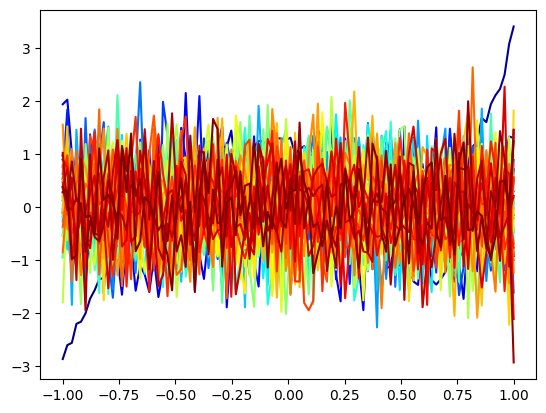

In [587]:
ufpca_cov_a_comp = UFPCA(n_components=0.99, method="covariance")
ufpca_cov_a_comp.fit(data)

_ = plot(ufpca_cov_a_comp.eigenfunctions)
plt.show()

Due to the high noise level, the adaptive method selected an excessive number of components (e.g., 51 components), far exceeding the true polynomial order.

In [588]:
ufpca_cov_a_comp.eigenfunctions

Functional data object with 51 observations on a 1-dimensional support.

In [589]:
scores_pace_a_comp = ufpca_cov_a_comp.transform(data, method="PACE")

### Observation
The reconstruction did not improve compared to the exact method, and the additional components mostly modeled noise rather than the underlying function structure.

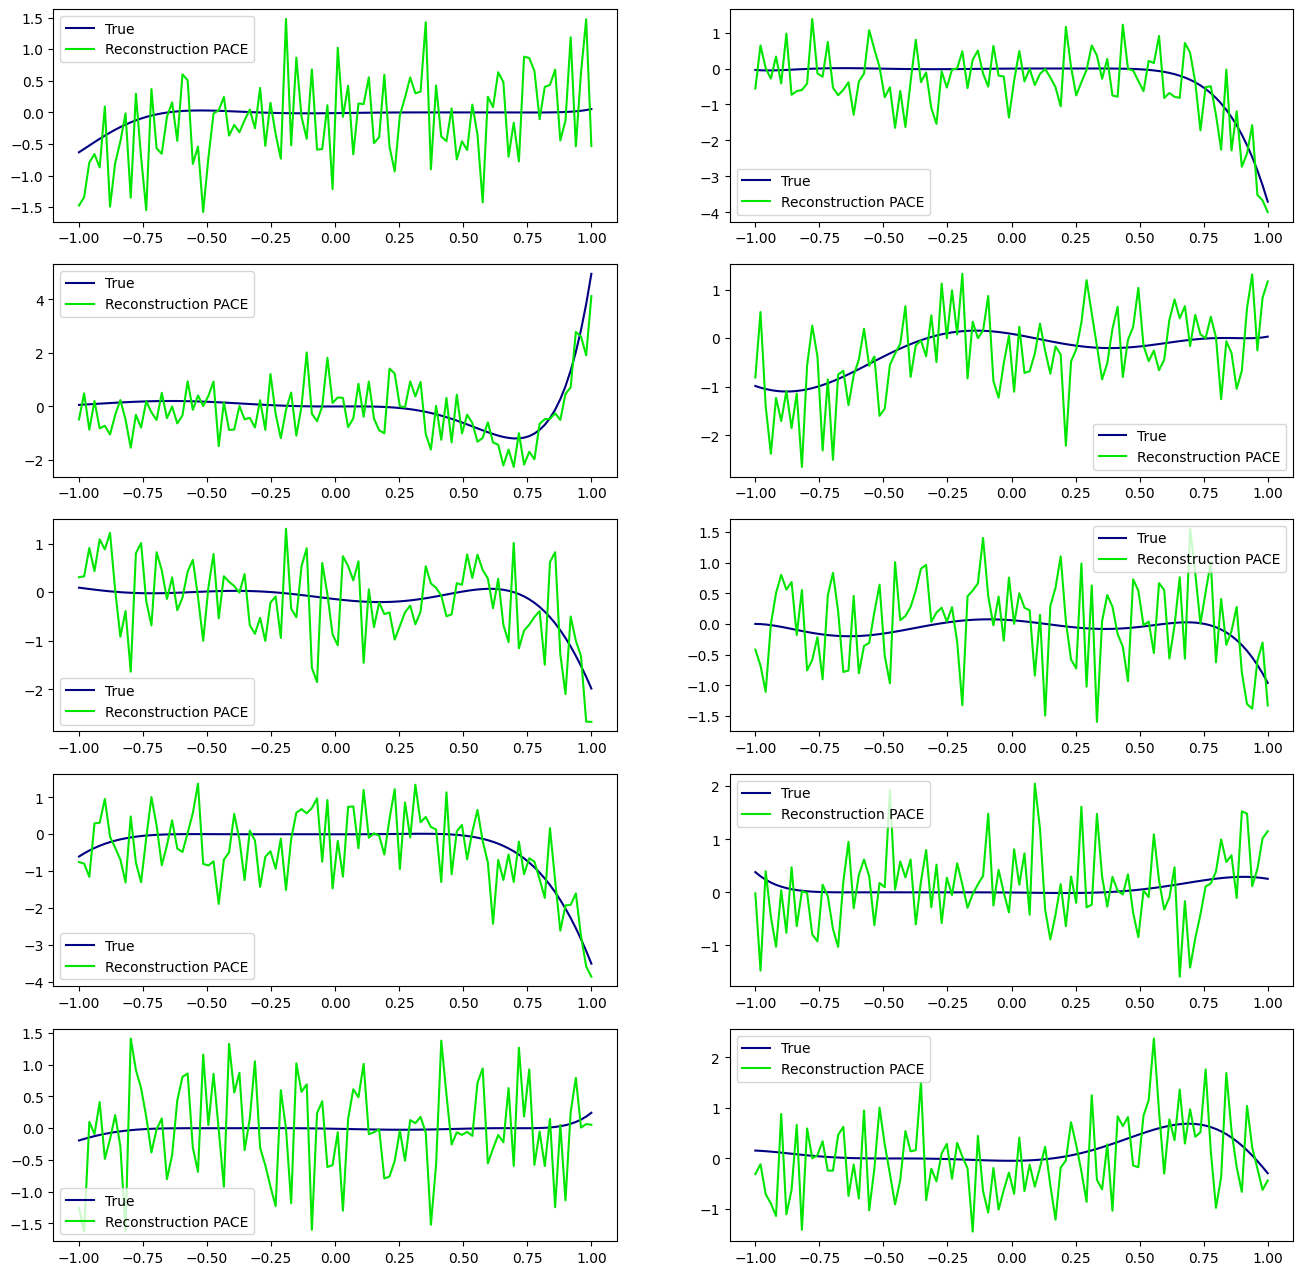

In [590]:
data_recons_pace = ufpca_cov_a_comp.inverse_transform(scores_pace_a_comp)
colors_pace = np.array([[0, 0.9, 0, 1]])

np.random.seed(3)

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 16))
for idx_plot, idx in enumerate(np.random.choice(function_count, 10)):
    temp_ax = axes.flatten()[idx_plot]
    temp_ax = plot(data_true[idx], ax=temp_ax, label="True")
    plot(
        data_recons_pace[idx],
        colors=colors_pace,
        ax=temp_ax,
        label="Reconstruction PACE",
    )
    temp_ax.legend()
plt.show()

# Conclusions

 1. Component Selection:
    - When the underlying functions are complex (e.g., near zero where multiple polynomial terms interact), an insufficient number of components fails to capture the signal. Using the exact number or an adaptive method (if noise is moderate) leads to better reconstructions.
    - In domains where one term dominates (non‑neighborhood of zero), even a low number of components may suffice.
    
2. Impact of Noise: In scenarios with high noise relative to the signal, all methods struggle to recover the underlying function. Adaptive selection may overestimate the number of components by capturing noise variance.
3. Practical Considerations: A proper balance between the number of components and the noise level is crucial. For well‑posed problems where the signal is clearly defined, adaptive methods can approximate the true underlying structure. In cases where noise dominates, additional preprocessing or noise reduction techniques are needed before applying FPCA.

This analysis emphasizes that while FPCA is a powerful tool for extracting smooth functional components, its performance is sensitive to the choice of components and the relative noise level in the data.